In [4]:
# ============================================
# CELL 1: Setup
# ============================================
!pip install -q rank_bm25 sentence-transformers faiss-cpu nltk matplotlib

import numpy as np
import re
import logging
from typing import List, Dict, Tuple
from dataclasses import dataclass

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger("hybrid_search")

STOPWORDS = set(stopwords.words('english'))

In [5]:
# ============================================
# CELL 2: Reuse tokenizer + corpus from the Dense vs Sparse lesson
# ============================================

def preprocess_text(text: str, remove_stopwords: bool = True) -> List[str]:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = word_tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens


corpus = [
    "Our return policy allows customers to send back items within 30 days for a full refund.",
    "If you're unhappy with a purchase, you can request money back within a month of buying it.",
    "Machine learning models can automatically detect fraudulent transactions in real time.",
    "AI systems are increasingly used to flag suspicious financial activity as it happens.",
    "Employees can request remote work arrangements through the HR portal.",
    "Staff members may apply for work-from-home setups via the internal HR system.",
    "Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.",
    "Error code E-4099 means the shipping address failed validation. Check the ZIP code field.",
    "Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse.",
    "Product SKU-88214-B is the wired keyboard model, available in all regions.",
    "Invoice #INV-2024-11837 was issued on March 3rd for account holder J. Martinez.",
    "Invoice #INV-2024-11902 was issued on March 9th for account holder R. Chen.",
    "The company's quarterly earnings report will be released next Thursday.",
    "New office locations are opening in Austin and Denver next quarter.",
]
logger.info(f"Corpus size: {len(corpus)}")

In [6]:
# ============================================
# CELL 3: Retriever classes (sparse + dense), production-structured
# ============================================

class SparseRetriever:
    def __init__(self, documents: List[str]):
        self.documents = documents
        self.tokenized_docs = [preprocess_text(d) for d in documents]
        self.bm25 = BM25Okapi(self.tokenized_docs)

    def search(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Returns list of (doc_id, raw_bm25_score), ranked descending."""
        scores = self.bm25.get_scores(preprocess_text(query))
        ranked_idx = np.argsort(scores)[::-1][:top_k]
        return [(int(i), float(scores[i])) for i in ranked_idx if scores[i] > 0]


class DenseRetriever:
    def __init__(self, documents: List[str], model_name: str = "all-MiniLM-L6-v2"):
        self.documents = documents
        self.model = SentenceTransformer(model_name)
        self.dim = self.model.get_embedding_dimension()

        embeddings = self.model.encode(documents, show_progress_bar=False).astype("float32")
        faiss.normalize_L2(embeddings)
        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)

    def search(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Returns list of (doc_id, cosine_similarity_score), ranked descending."""
        q_emb = self.model.encode([query]).astype("float32")
        faiss.normalize_L2(q_emb)
        scores, indices = self.index.search(q_emb, top_k)
        return [(int(idx), float(score)) for score, idx in zip(scores[0], indices[0]) if idx != -1]


sparse_retriever = SparseRetriever(corpus)
dense_retriever = DenseRetriever(corpus)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
# ============================================
# CELL 4: PRODUCTION HYBRID FUSION ENGINE
# Implements both RRF and weighted-normalization fusion, with logging,
# input validation, and clean typed interfaces — structured the way
# you'd actually ship this in a retrieval service.
# ============================================

@dataclass
class FusedResult:
    doc_id: int
    document: str
    fused_score: float
    sparse_score: float = None
    dense_score: float = None
    sparse_rank: int = None
    dense_rank: int = None


class HybridSearchEngine:
    """
    Combines a SparseRetriever and DenseRetriever using either:
      - Reciprocal Rank Fusion (RRF)  [recommended default]
      - Weighted min-max score normalization
    """

    def __init__(self, sparse_retriever: SparseRetriever, dense_retriever: DenseRetriever, documents: List[str]):
        if sparse_retriever.documents != dense_retriever.documents:
            raise ValueError(
                "Sparse and dense retrievers were built on different document sets/chunking — "
                "this is a real production bug (see Gap Check / pitfall #3)."
            )
        self.sparse = sparse_retriever
        self.dense = dense_retriever
        self.documents = documents

    # ---------- Strategy 1: RRF ----------
    def search_rrf(self, query: str, top_k: int = 5, candidate_k: int = 30, rrf_k: int = 60) -> List[FusedResult]:
        sparse_results = self.sparse.search(query, top_k=candidate_k)
        dense_results = self.dense.search(query, top_k=candidate_k)

        sparse_ranks = {doc_id: rank + 1 for rank, (doc_id, _) in enumerate(sparse_results)}
        dense_ranks = {doc_id: rank + 1 for rank, (doc_id, _) in enumerate(dense_results)}
        sparse_scores = dict(sparse_results)
        dense_scores = dict(dense_results)

        all_doc_ids = set(sparse_ranks) | set(dense_ranks)
        fused = []
        for doc_id in all_doc_ids:
            score = 0.0
            if doc_id in sparse_ranks:
                score += 1.0 / (rrf_k + sparse_ranks[doc_id])
            if doc_id in dense_ranks:
                score += 1.0 / (rrf_k + dense_ranks[doc_id])

            fused.append(FusedResult(
                doc_id=doc_id,
                document=self.documents[doc_id],
                fused_score=score,
                sparse_score=sparse_scores.get(doc_id),
                dense_score=dense_scores.get(doc_id),
                sparse_rank=sparse_ranks.get(doc_id),
                dense_rank=dense_ranks.get(doc_id),
            ))

        fused.sort(key=lambda r: r.fused_score, reverse=True)
        logger.info(f"RRF fusion: {len(sparse_results)} sparse + {len(dense_results)} dense -> {len(fused)} unique candidates")
        return fused[:top_k]

    # ---------- Strategy 2: Weighted normalization ----------
    @staticmethod
    def _min_max_normalize(scores: Dict[int, float]) -> Dict[int, float]:
        if not scores:
            return {}
        values = list(scores.values())
        lo, hi = min(values), max(values)
        if hi == lo:  # avoid divide-by-zero when all scores are identical
            return {k: 1.0 for k in scores}
        return {k: (v - lo) / (hi - lo) for k, v in scores.items()}

    def search_weighted(self, query: str, top_k: int = 5, candidate_k: int = 30, alpha: float = 0.5) -> List[FusedResult]:
        if not (0.0 <= alpha <= 1.0):
            raise ValueError("alpha must be between 0 and 1")

        sparse_results = dict(self.sparse.search(query, top_k=candidate_k))
        dense_results = dict(self.dense.search(query, top_k=candidate_k))

        norm_sparse = self._min_max_normalize(sparse_results)
        norm_dense = self._min_max_normalize(dense_results)

        all_doc_ids = set(sparse_results) | set(dense_results)
        fused = []
        for doc_id in all_doc_ids:
            s = norm_sparse.get(doc_id, 0.0)
            d = norm_dense.get(doc_id, 0.0)
            score = alpha * d + (1 - alpha) * s
            fused.append(FusedResult(
                doc_id=doc_id,
                document=self.documents[doc_id],
                fused_score=score,
                sparse_score=sparse_results.get(doc_id),
                dense_score=dense_results.get(doc_id),
            ))

        fused.sort(key=lambda r: r.fused_score, reverse=True)
        logger.info(f"Weighted fusion (alpha={alpha}): {len(fused)} unique candidates")
        return fused[:top_k]


hybrid = HybridSearchEngine(sparse_retriever, dense_retriever, corpus)

In [10]:
# ============================================
# CELL 5: Compare all three approaches side-by-side on the same queries
# ============================================

def print_results(title: str, results: List[FusedResult]):
    print(f"\n--- {title} ---")
    for r in results:
        parts = [f"fused={r.fused_score:.4f}"]
        if r.sparse_score is not None:
            parts.append(f"BM25={r.sparse_score:.2f}")
        if r.dense_score is not None:
            parts.append(f"cos={r.dense_score:.3f}")
        if r.sparse_rank is not None:
            parts.append(f"sparse_rank={r.sparse_rank}")
        if r.dense_rank is not None:
            parts.append(f"dense_rank={r.dense_rank}")
        print(f"  [{' | '.join(parts)}] {r.document}")


test_queries = [
    "Can I get my money back after buying something?",          # conceptual -> dense should help
    "What does error E-4021 mean?",                              # exact ID -> sparse should help
    "wireless keyboard SKU-88213-A availability",                # mixed
]

for q in test_queries:
    print(f"\n{'='*80}\nQUERY: \"{q}\"\n{'='*80}")
    print_results("RRF Fusion", hybrid.search_rrf(q, top_k=3))
    print_results("Weighted Fusion (alpha=0.5)", hybrid.search_weighted(q, top_k=3, alpha=0.5))
    print_results("Weighted Fusion (alpha=0.2, sparse-favored)", hybrid.search_weighted(q, top_k=3, alpha=0.2))


QUERY: "Can I get my money back after buying something?"

--- RRF Fusion ---
  [fused=0.0328 | BM25=6.42 | cos=0.748 | sparse_rank=1 | dense_rank=1] If you're unhappy with a purchase, you can request money back within a month of buying it.
  [fused=0.0323 | BM25=1.43 | cos=0.487 | sparse_rank=2 | dense_rank=2] Our return policy allows customers to send back items within 30 days for a full refund.
  [fused=0.0159 | cos=0.206 | dense_rank=3] Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.

--- Weighted Fusion (alpha=0.5) ---
  [fused=1.0000 | BM25=6.42 | cos=0.748] If you're unhappy with a purchase, you can request money back within a month of buying it.
  [fused=0.3474 | BM25=1.43 | cos=0.487] Our return policy allows customers to send back items within 30 days for a full refund.
  [fused=0.1837 | cos=0.206] Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.

--- Weighted Fusion (alpha=0.2, sparse-

In [11]:
# ============================================
# CELL 6: Demonstrate the outlier-sensitivity problem in weighted normalization
# (This is the concrete proof for why RRF is generally preferred)
# ============================================

# Inject an artificial outlier: a document that will get an abnormally
# high BM25 score for a specific rare term, to show how it distorts
# min-max normalization for the WHOLE candidate set.
outlier_corpus = corpus + [
    "zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx rare term stuffing example document."
]

outlier_sparse = SparseRetriever(outlier_corpus)
outlier_dense = DenseRetriever(outlier_corpus)
outlier_hybrid = HybridSearchEngine(outlier_sparse, outlier_dense, outlier_corpus)

query = "zzqx term meaning"

print("Raw BM25 scores (notice the outlier's huge score vs everything else):")
for doc_id, score in outlier_sparse.search(query, top_k=5):
    print(f"  {score:.2f} | {outlier_corpus[doc_id][:60]}")

print("\n--- Weighted fusion gets distorted by the outlier ---")
print_results("Weighted (alpha=0.5)", outlier_hybrid.search_weighted(query, top_k=5, alpha=0.5))

print("\n--- RRF is unaffected — it never looks at the raw score magnitude ---")
print_results("RRF", outlier_hybrid.search_rrf(query, top_k=5))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Raw BM25 scores (notice the outlier's huge score vs everything else):
  6.51 | zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx rare term 

--- Weighted fusion gets distorted by the outlier ---

--- Weighted (alpha=0.5) ---
  [fused=1.0000 | BM25=6.51 | cos=0.470] zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx zzqx rare term stuffing example document.
  [fused=0.1574 | cos=0.079] Invoice #INV-2024-11837 was issued on March 3rd for account holder J. Martinez.
  [fused=0.1538 | cos=0.075] Invoice #INV-2024-11902 was issued on March 9th for account holder R. Chen.
  [fused=0.1470 | cos=0.068] If you're unhappy with a purchase, you can request money back within a month of buying it.
  [fused=0.1389 | cos=0.058] Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse.

--- RRF is unaffected — it never looks at the raw score magnitude ---

--- RRF ---
  [fused=0.0328 | BM25=6.51 | cos=0.470 | sparse_rank=1 | dense_rank=1] zzqx zzqx zzqx zzqx zzqx zzqx zz

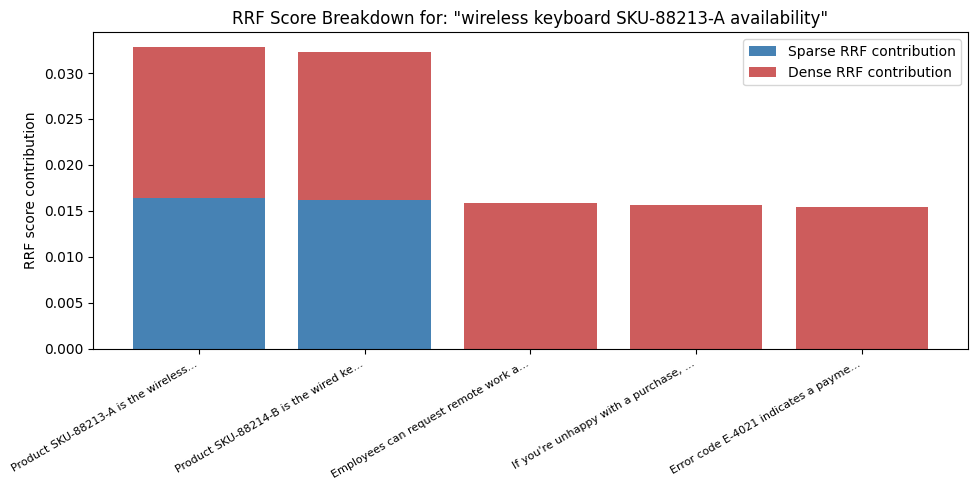

Notice: top results are usually the ones BOTH methods agree on (tall combined bars),
this is RRF rewarding cross-method agreement as a relevance signal.


In [12]:
# ============================================
# CELL 7: Visualization — RRF score contribution breakdown
# ============================================

import matplotlib.pyplot as plt

query = "wireless keyboard SKU-88213-A availability"
results = hybrid.search_rrf(query, top_k=5, rrf_k=60)

labels = [r.document[:35] + "..." for r in results]
sparse_contrib = [1.0 / (60 + r.sparse_rank) if r.sparse_rank else 0 for r in results]
dense_contrib = [1.0 / (60 + r.dense_rank) if r.dense_rank else 0 for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
ax.bar(x, sparse_contrib, label="Sparse RRF contribution", color="steelblue")
ax.bar(x, dense_contrib, bottom=sparse_contrib, label="Dense RRF contribution", color="indianred")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("RRF score contribution")
ax.set_title(f"RRF Score Breakdown for: \"{query}\"")
ax.legend()
plt.tight_layout()
plt.show()

print("Notice: top results are usually the ones BOTH methods agree on (tall combined bars),")
print("this is RRF rewarding cross-method agreement as a relevance signal.")